## Install Requirements

In [ ]:
!pip install -q transformers datasets evaluate seqeval accelerate matplotlib seaborn tabulate numpy pandas nltk kagglehub scikit-learn imbalanced-learn

In [ ]:
import csv, json, os, random, re, glob, inspect
from collections import Counter
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch.nn as nn
from tabulate import tabulate

import nltk
import kagglehub
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)

import torch
import torch.nn.functional as F
from datasets import Dataset, DatasetDict
import evaluate
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    Trainer,
    TrainerCallback,
    TrainingArguments,
)

# **CONFIG**

In [ ]:
MODEL_NAME           = "roberta-base"
OUTPUT_DIR           = "./cv_parser_roberta"
DATATURKS_PATH       = "Entity Recognition in Resumes.json"
SNEHAANBHAWAL_PATH   = "Resume.csv"
SYNTHETIC_PATH       = "synthetic_cv_dataset.json"
N_SYNTHETIC          = 500
MAX_LEN              = 256
BATCH_SIZE           = 16
EPOCHS               = 5
LR                   = 2e-5
TRAIN_RATIO          = 0.80
VAL_RATIO            = 0.10
TEST_RATIO           = 0.10
CONFIDENCE_THRESHOLD = 0.6

LABEL_LIST = [
    "O",
    "B-NAME",             "I-NAME",
    "B-CONTACT",          "I-CONTACT",
    "B-ABOUT",            "I-ABOUT",

    "B-EXP_JOB_TITLE",   "I-EXP_JOB_TITLE",
    "B-EXP_COMPANY",     "I-EXP_COMPANY",
    "B-EXP_START_DATE",  "I-EXP_START_DATE",
    "B-EXP_END_DATE",    "I-EXP_END_DATE",
    "B-EXP_LOCATION",    "I-EXP_LOCATION",
    "B-EXP_DESCRIPTION", "I-EXP_DESCRIPTION",

    "B-EDU_SCHOOL",      "I-EDU_SCHOOL",
    "B-EDU_DEGREE",      "I-EDU_DEGREE",
    "B-EDU_FIELD",       "I-EDU_FIELD",
    "B-EDU_START_DATE",  "I-EDU_START_DATE",
    "B-EDU_END_DATE",    "I-EDU_END_DATE",
    "B-EDU_GRADE",       "I-EDU_GRADE",
    "B-EDU_DESCRIPTION", "I-EDU_DESCRIPTION",

    "B-PROJ_TITLE",      "I-PROJ_TITLE",
    "B-PROJ_DESCRIPTION","I-PROJ_DESCRIPTION",
    "B-PROJ_ROLE",       "I-PROJ_ROLE",
    "B-PROJ_URL",        "I-PROJ_URL",
    "B-PROJ_DATE",       "I-PROJ_DATE",

    "B-SKILLS",           "I-SKILLS",
]
LABEL2ID = {l: i for i, l in enumerate(LABEL_LIST)}
ID2LABEL  = {i: l for l, i in LABEL2ID.items()}

# **SYNTHETIC DATASET**

In [ ]:
FIRST_NAMES = [
    "Andi","Budi","Citra","Dian","Eka","Fajar","Gita","Hendra",
    "Indra","Joko","Kevin","Lina","Maya","Nanda","Oscar","Putri",
    "Rafi","Sari","Toni","Umar","Vina","Wahyu","Yusuf","Zara",
    "Arya","Bella","Cahyo","Dewi","Evan","Fira","Gilang","Hani",
    "Irfan","Jasmine","Kurnia","Layla","Marco","Nina","Oliver",
    "Pita","Reza","Sinta","Tama","Ulfa","Vito","Wendi","Yanti",
    "Ahmad","Bagas","Chelsea","David","Elisa","Farhan","Grace",
]
LAST_NAMES = [
    "Santoso","Wijaya","Pratama","Kusuma","Rahayu","Hidayat",
    "Permana","Susanto","Wibowo","Putra","Sari","Nugroho",
    "Maulana","Saputra","Utama","Firmansyah","Hakim","Setiawan",
    "Gunawan","Hartono","Andriani","Budiarto","Cahyono","Darmawan",
    "Effendi","Fauzi","Ginting","Handoko","Iswanto","Junaidi",
]
CITIES_ID     = ["Jakarta","Bandung","Surabaya","Yogyakarta","Semarang",
                 "Medan","Makassar","Bali","Malang","Depok","Bekasi","Tangerang"]
CITIES_GLOBAL = ["Singapore","Kuala Lumpur","Sydney","London","Amsterdam",
                 "Berlin","Tokyo","Seoul","San Francisco","New York"]
ALL_CITIES    = CITIES_ID + CITIES_GLOBAL
EMAILS   = ["{f}.{l}@gmail.com","{f}{l}@yahoo.com","{f}.{l}@outlook.com","{f}_{l}@proton.me"]
PHONES   = ["+62 812 {a} {b}","+62 857 {a} {b}","+62 821 {a} {b}","0812-{a}-{b}"]
LI_TPLS  = ["linkedin.com/in/{f}-{l}","linkedin.com/in/{f}{l}","linkedin.com/in/{f}-{l}-dev"]
GH_TPLS  = ["github.com/{f}{l}","github.com/{f}-{l}","github.com/{f}dev"]
ABOUT_TPLS = [
    "Passionate {role} with {yrs}+ years of experience building scalable web applications. "
    "Strong background in {stack}. Committed to clean, maintainable code and impactful UX.",
    "Results-driven {role} specializing in {stack}. {yrs} years of hands-on experience "
    "developing end-to-end solutions for startups and enterprises.",
    "Creative {role} with a focus on {stack}. Experienced in leading cross-functional teams "
    "and shipping products from ideation to production. {yrs}+ years in the industry.",
    "Full-stack developer and {role} with expertise in {stack}. Passionate about open-source "
    "contributions and building products that solve real-world problems.",
    "Dedicated {role} with {yrs} years of experience in {stack}. Proven track record of "
    "delivering high-quality software on time.",
]
ROLES  = ["Software Engineer","Full Stack Developer","Backend Developer","Frontend Developer",
          "Mobile Developer","Data Engineer","DevOps Engineer","Machine Learning Engineer",
          "Cloud Architect","Product Engineer"]
STACKS = ["React, Node.js, and PostgreSQL","Python, FastAPI, and Docker",
          "Flutter, Firebase, and REST APIs","Vue.js, Laravel, and MySQL",
          "React Native, TypeScript, and GraphQL","Django, Celery, and Redis",
          "Next.js, Prisma, and Vercel","Spring Boot, Kafka, and Kubernetes",
          "Go, gRPC, and MongoDB","Angular, .NET Core, and Azure"]
COMPANIES  = ["Tokopedia","Gojek","Traveloka","Bukalapak","OVO","Dana","Shopee","Lazada",
              "Grab","Ruangguru","Zenius","Koinworks","Ajaib","Bibit","Stockbit","Tiket.com",
              "Blibli","Midtrans","Xendit","Flip","Kredivo","Accenture","IBM Indonesia",
              "Microsoft Indonesia","Google Indonesia","Startup Alpha","TechCorp ID",
              "DataVision","CloudBase","Nexoft","Nodeflux","Kata.ai","Prosa.ai","Adira Finance"]
JOB_TITLES = ["Software Engineer","Senior Software Engineer","Backend Engineer","Frontend Engineer",
              "Full Stack Engineer","Lead Engineer","Mobile Developer","DevOps Engineer",
              "Data Engineer","Platform Engineer","API Developer","Solutions Architect",
              "Junior Software Engineer","Staff Engineer","Principal Engineer"]
EXP_DESCS  = [
    "Developed and maintained microservices handling {n}k+ daily active users.",
    "Led migration of monolithic system to microservices, reducing latency by {p}%.",
    "Built RESTful APIs consumed by {n} internal and external services.",
    "Implemented CI/CD pipelines reducing deployment time by {p}%.",
    "Mentored a team of {n} junior developers and conducted weekly code reviews.",
    "Designed database schema for high-throughput transactional systems.",
    "Collaborated with product and design teams to ship {n} major features per quarter.",
    "Improved system reliability, achieving {p}% uptime SLA.",
    "Integrated third-party payment gateways and fraud detection systems.",
    "Refactored legacy codebase, reducing technical debt by {p}%.",
    "Architected event-driven system using Kafka processing {n}k events per second.",
    "Optimized SQL queries reducing average response time by {p}%.",
    "Delivered {n} end-to-end features across web and mobile platforms.",
    "Built internal tooling adopted by {n}+ engineering teams company-wide.",
]
UNIVERSITIES = ["Universitas Indonesia","Institut Teknologi Bandung","Universitas Gadjah Mada",
                "Institut Teknologi Sepuluh Nopember","Universitas Brawijaya","Universitas Diponegoro",
                "Universitas Binus","Universitas Telkom","Universitas Airlangga","Universitas Padjadjaran",
                "Nanyang Technological University","National University of Singapore",
                "University of Melbourne","RMIT University"]
DEGREES      = ["Bachelor of Science","Bachelor of Engineering","Bachelor of Computer Science",
                "Master of Science","Master of Engineering","Diploma III"]
FIELDS       = ["Computer Science","Informatics Engineering","Information Systems",
                "Electrical Engineering","Mathematics","Statistics","Data Science",
                "Software Engineering","Artificial Intelligence","Cybersecurity"]
EDU_DESCS    = [
    "Focused on {field} with coursework in algorithms, data structures, and software engineering.",
    "Specialized in {field}. Thesis on machine learning applications in NLP.",
    "Graduated with honors. Active in coding competitions and open-source contributions.",
    "Completed {field} program with strong emphasis on distributed systems and cloud computing.",
    "Dean's list recipient. Participated in national hackathon and software engineering competitions.",
    "Concentrated in {field}, with final project on microservices architecture.",
]
SKILL_POOLS = {
    "languages": ["Python","JavaScript","TypeScript","Go","Java","Kotlin","Swift","Dart","PHP","Rust","C++","C#"],
    "frontend":  ["React","Vue.js","Angular","Next.js","Nuxt.js","Svelte","Tailwind CSS","Bootstrap","Redux"],
    "backend":   ["Node.js","FastAPI","Django","Flask","Laravel","Express","Spring Boot","NestJS","GraphQL","gRPC"],
    "mobile":    ["Flutter","React Native","Android","iOS","Expo"],
    "database":  ["PostgreSQL","MySQL","MongoDB","Redis","Elasticsearch","Firestore","SQLite","DynamoDB"],
    "devops":    ["Docker","Kubernetes","CI/CD","GitHub Actions","Jenkins","AWS","GCP","Azure","Terraform","Linux"],
    "tools":     ["Git","Jira","Figma","Postman","VS Code","IntelliJ","Slack","Notion"],
    "ml":        ["TensorFlow","PyTorch","scikit-learn","Pandas","NumPy","Hugging Face","OpenCV","LangChain"],
}
PROJECT_TITLES = [
    "E-Commerce Platform","Food Delivery App","Personal Finance Tracker","Job Board Platform",
    "Real-Time Chat Application","Online Learning Management System","Inventory Management System",
    "Healthcare Appointment Booking","Social Media Dashboard","Hotel Booking System",
    "Task Management Tool","Expense Tracker Mobile App","News Aggregator API",
    "Open Source CLI Tool for Data Migration","AI-Powered Resume Parser","Fraud Detection System",
    "Event Ticketing Platform","Multi-Vendor Marketplace","IoT Dashboard for Smart Home",
    "Crypto Portfolio Tracker","URL Shortener Service","Customer Support Chatbot",
    "Document OCR Pipeline","Microservices Boilerplate","GraphQL API Gateway",
    "Real Estate Listing Platform","Employee Attendance System","Content Management System",
]
PROJ_DESCS = [
    "Built a full-stack {title} using {stack}. Supports {f1} and {f2}, serving {n}k+ users.",
    "Developed {title} with {stack}. Features include {f1}, {f2}, and real-time WebSocket notifications.",
    "Designed a scalable {title} leveraging {stack}. Achieved {p}% performance gain through caching.",
    "Open-source {title} built with {stack}. {n}+ GitHub stars, actively maintained.",
    "End-to-end {title} with {f1} and {f2}. Integrated with {integ} for seamless experience.",
    "Cloud-native {title} on AWS using {stack}. Handles {n}k+ concurrent users at 99.9% uptime.",
    "Mobile-first {title} with {stack}. Published on Play Store and App Store with {n}k+ downloads.",
    "Microservices-based {title} using {stack}. Each service independently deployable via Docker.",
]
FEATURES     = ["user authentication","real-time updates","payment integration","push notifications",
                "role-based access control","multi-language support","dark mode","PDF export",
                "data visualization","OAuth login","email notifications","file upload",
                "search and filter","two-factor authentication","admin dashboard","analytics tracking"]
INTEGRATIONS = ["Midtrans payment gateway","Stripe","Firebase Auth","Google Maps API",
                "Twilio SMS","SendGrid email","Cloudinary CDN","AWS S3","Google Analytics"]
PROJ_ROLES   = ["Full Stack Developer","Backend Developer","Frontend Developer","Mobile Developer",
                "Lead Developer","Solo Developer","API Developer","Tech Lead"]
URL_TPLS     = ["github.com/{f}{l}/{slug}","github.com/{f}-{l}/{slug}",
                "{slug}.vercel.app","{slug}.netlify.app","demo.{slug}.io"]

In [ ]:
def _rand_date(y0=2015, y1=2024):
    s = datetime(y0, 1, 1); e = datetime(y1, 12, 31)
    return s + timedelta(days=random.randint(0, (e - s).days))

def _fmt(dt, style="month_year"):
    if style == "month_year": return dt.strftime("%B %Y")
    if style == "short":      return dt.strftime("%b %Y")
    if style == "year":       return str(dt.year)
    return dt.strftime("%Y-%m-%d")

def _slugify(t): return t.lower().replace(" ", "-")

def _sample_skills(n=7):
    pool = []
    for cat in random.sample(list(SKILL_POOLS), k=min(4, len(SKILL_POOLS))):
        pool += SKILL_POOLS[cat]
    return random.sample(list(set(pool)), k=min(n, len(pool)))

In [ ]:
def _gen_contact(f, l, city):
    email = random.choice(EMAILS).format(f=f.lower(), l=l.lower())
    phone = random.choice(PHONES).format(a=random.randint(1000,9999), b=random.randint(1000,9999))
    li    = random.choice(LI_TPLS).format(f=f.lower(), l=l.lower())
    gh    = random.choice(GH_TPLS).format(f=f.lower(), l=l.lower())
    parts = [email, phone, city]
    if random.random() > 0.3: parts.append(li)
    if random.random() > 0.5: parts.append(gh)
    return {"text": " | ".join(parts), "email": email, "phone": phone,
            "city": city, "linkedin": li, "github": gh}

def _gen_experience(n_jobs=2):
    jobs, end_dt = [], datetime.now()
    for i in range(n_jobs):
        dur      = random.randint(10, 36)
        start_dt = end_dt - timedelta(days=dur * 30)
        is_cur   = (i == 0)
        sty      = random.choice(["month_year", "short"])
        desc     = random.choice(EXP_DESCS).format(n=random.randint(2, 500), p=random.randint(10, 80))
        jobs.append({
            "job_title":   random.choice(JOB_TITLES),
            "company":     random.choice(COMPANIES),
            "start_date":  _fmt(start_dt, sty),
            "end_date":    "Present" if is_cur else _fmt(end_dt, sty),
            "location":    random.choice(ALL_CITIES),
            "description": desc,
        })
        end_dt = start_dt - timedelta(days=random.randint(0, 60))
    return jobs

def _gen_education():
    grad_year  = random.randint(2010, 2022)
    start_year = grad_year - random.choice([3, 4])
    field      = random.choice(FIELDS)
    sty        = random.choice(["month_year", "short", "year"])
    start_dt   = datetime(start_year, random.randint(1, 9), 1)
    end_dt     = datetime(grad_year,  random.randint(5, 12), 1)
    desc       = random.choice(EDU_DESCS).format(field=field)
    grade      = None
    if random.random() > 0.4:
        grade = random.choice([
            f"{random.uniform(3.0, 3.95):.2f} / 4.00",
            "First Class Honours", "Cum Laude",
            f"GPA {random.uniform(3.0, 3.95):.2f}",
        ])
    return {"school": random.choice(UNIVERSITIES), "degree": random.choice(DEGREES),
            "field_of_study": field, "start_date": _fmt(start_dt, sty),
            "end_date": _fmt(end_dt, sty), "grade": grade, "description": desc}

def _gen_portfolio(f, l, n=3):
    projects, used = [], set()
    for _ in range(n):
        title = random.choice(PROJECT_TITLES)
        while title in used: title = random.choice(PROJECT_TITLES)
        used.add(title)
        stack = random.choice(STACKS)
        f1    = random.choice(FEATURES)
        f2    = random.choice([x for x in FEATURES if x != f1])
        desc  = random.choice(PROJ_DESCS).format(
            title=title, stack=stack, f1=f1, f2=f2,
            integ=random.choice(INTEGRATIONS),
            n=random.randint(1, 100), p=random.randint(10, 90))
        comp_date = _fmt(_rand_date(2018, 2024), random.choice(["month_year","short","year"]))
        role = random.choice(PROJ_ROLES) if random.random() < 0.70 else None
        url  = random.choice(URL_TPLS).format(
                   f=f.lower(), l=l.lower(), slug=_slugify(title)
               ) if random.random() < 0.60 else None
        projects.append({"title": title, "description": desc,
                         "role": role, "url": url, "date": comp_date})
    return projects

In [ ]:
def _render_cv(f, l, contact, about, experience, education, skills, portfolio):
    lines = [f"{f} {l}", contact["text"], ""]
    lines += [random.choice(["SUMMARY","ABOUT ME","PROFESSIONAL SUMMARY","PROFILE","OBJECTIVE"]),
              about, ""]
    lines.append(random.choice(["EXPERIENCE","WORK EXPERIENCE","PROFESSIONAL EXPERIENCE"]))
    for job in experience:
        lines += [
            job["job_title"],
            job["company"],
            job["location"],
            job["start_date"],
            job["end_date"],
            job["description"], ""
        ]
    lines.append(random.choice(["EDUCATION","EDUCATIONAL BACKGROUND","ACADEMIC BACKGROUND"]))
    edu = education
    lines += [
        edu["degree"],
        edu["field_of_study"],
        edu["school"],
        edu["start_date"],
        edu["end_date"],
    ]
    if edu.get("grade"): lines.append("Grade: " + edu["grade"])
    lines += [edu["description"], ""]
    lines.append(random.choice(["SKILLS","TECHNICAL SKILLS","CORE COMPETENCIES","TECHNOLOGIES"]))
    fmt_s = random.choice(["comma","bullet","line"])
    if fmt_s == "comma":    lines.append(", ".join(skills))
    elif fmt_s == "bullet": lines += [f"• {s}" for s in skills]
    else:                   lines += skills
    lines.append("")
    lines.append(random.choice(["PORTFOLIO","PROJECTS","PROJECT PORTFOLIO","PERSONAL PROJECTS"]))
    for proj in portfolio:
        lines.append(proj["title"])
        lines.append(proj["description"])
        if proj.get("role"): lines.append(proj["role"])
        if proj.get("url"):  lines.append(proj["url"])
        lines += [proj["date"], ""]
    return "\n".join(lines)

In [ ]:
def _annotate_cv(cv_orig, f, l, contact, about, experience, education, skills, portfolio):
    char_labels = ["O"] * len(cv_orig)

    def label_span(needle, lbl):
        """Label all characters of the first occurrence of needle."""
        if not needle: return
        idx = cv_orig.find(needle)
        if idx == -1: return
        for i in range(idx, idx + len(needle)):
            char_labels[i] = lbl

    label_span(f"{f} {l}", "NAME")
    for v in [contact["email"], contact["phone"], contact["city"],
              contact["linkedin"], contact["github"]]:
        if v: label_span(v, "CONTACT")

    label_span(about, "ABOUT")

    for job in experience:
        label_span(job["job_title"],   "EXP_JOB_TITLE")
        label_span(job["company"],     "EXP_COMPANY")
        label_span(job["location"],    "EXP_LOCATION")
        label_span(job["start_date"],  "EXP_START_DATE")
        label_span(job["end_date"],    "EXP_END_DATE")
        label_span(job["description"], "EXP_DESCRIPTION")

    edu = education
    label_span(edu["degree"],         "EDU_DEGREE")
    label_span(edu["field_of_study"],  "EDU_FIELD")
    label_span(edu["school"],          "EDU_SCHOOL")
    label_span(edu["start_date"],      "EDU_START_DATE")
    label_span(edu["end_date"],        "EDU_END_DATE")
    label_span(edu["description"],     "EDU_DESCRIPTION")
    if edu.get("grade"):
        label_span(edu["grade"],       "EDU_GRADE")

    for proj in portfolio:
        label_span(proj["title"],       "PROJ_TITLE")
        label_span(proj["description"], "PROJ_DESCRIPTION")
        if proj.get("role"): label_span(proj["role"], "PROJ_ROLE")
        if proj.get("url"):  label_span(proj["url"],  "PROJ_URL")
        label_span(proj["date"],        "PROJ_DATE")

    for s in skills: label_span(s, "SKILLS")

    tokens, tags = [], []
    mut = cv_orig
    for word in cv_orig.split():
        idx = mut.find(word)
        if idx == -1:
            tokens.append(word); tags.append("O"); continue
        dominant = Counter(char_labels[idx: idx + len(word)]).most_common(1)[0][0]
        bio = ("O" if dominant == "O"
               else f"B-{dominant}" if (not tags or tags[-1] == "O" or tags[-1].split("-", 1)[-1] != dominant)
               else f"I-{dominant}")
        tokens.append(word); tags.append(bio)
        mut = mut[:idx] + " " * len(word) + mut[idx + len(word):]
    return {"tokens": tokens, "ner_tags": tags}

In [ ]:
def generate_synthetic_dataset(n_samples=500):
    print(f"\n🔧 Generating {n_samples} synthetic CVs...")
    samples = []
    for i in range(n_samples):
        f    = random.choice(FIRST_NAMES)
        l    = random.choice(LAST_NAMES)
        role = random.choice(ROLES)
        stk  = random.choice(STACKS)
        yrs  = random.randint(1, 12)
        city = random.choice(CITIES_ID)
        contact   = _gen_contact(f, l, city)
        about     = random.choice(ABOUT_TPLS).format(role=role, stack=stk, yrs=yrs)
        exp       = _gen_experience(n_jobs=random.randint(1, 3))
        edu       = _gen_education()
        skills    = _sample_skills(n=random.randint(5, 10))
        portfolio = _gen_portfolio(f, l, n=random.randint(2, 4))
        cv_text   = _render_cv(f, l, contact, about, exp, edu, skills, portfolio)
        sample    = _annotate_cv(cv_text, f, l, contact, about, exp, edu, skills, portfolio)
        samples.append(sample)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{n_samples} CVs generated...")
    print(f"Synthetic dataset done: {len(samples)} samples")
    return samples

# **Data Preparation**

In [ ]:
SECTION_KEYWORDS = {
    "ABOUT":      ["summary","about","objective","profile","about me","professional summary","career objective"],
    "EXPERIENCE": ["experience","work experience","employment","work history","professional experience","internship"],
    "EDUCATION":  ["education","academic","qualification","degree","educational background"],
    "SKILLS":     ["skills","technical skills","core competencies","competencies","expertise","technologies","tools"],
    "PORTFOLIO":  ["portfolio","projects","project","works","publications","open source","side projects","personal projects"],
    "CONTACT":    ["contact","email","phone","address","linkedin","github","website","personal info"],
}

In [ ]:
def _load_dataturks(filepath):
    DMAP = {
        "Name": "NAME", "Email Address": "CONTACT", "Phone Number": "CONTACT",
        "Location": "CONTACT", "Skills": "SKILLS", "College Name": "EDUCATION",
        "Degree": "EDUCATION", "Graduation Year": "EDUCATION",
        "Companies worked at": "EXPERIENCE", "Job Title": "EXPERIENCE",
        "Years of Experience": "EXPERIENCE", "Designation": "EXPERIENCE",
    }
    samples = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try: item = json.loads(line)
            except: continue
            text        = item.get("content", "")
            char_labels = ["O"] * len(text)
            for ann in (item.get("annotation") or []):
                raw    = ann.get("label", ["O"])
                raw    = raw[0] if isinstance(raw, list) else raw
                mapped = DMAP.get(raw)
                if not mapped: continue
                for pt in ann.get("points", []):
                    s, e = pt.get("start", 0), pt.get("end", 0)
                    for i in range(s, min(e + 1, len(text))):
                        char_labels[i] = mapped
            tokens, tags = [], []
            for word in text.split():
                idx = text.find(word)
                if idx == -1:
                    tokens.append(word); tags.append("O"); continue
                dominant = Counter(char_labels[idx: idx + len(word)]).most_common(1)[0][0]
                tokens.append(word); tags.append(dominant)
                text = text[:idx] + " " * len(word) + text[idx + len(word):]
            if tokens:
                samples.append({"tokens": tokens, "ner_tags": tags})
    print(f"[Dataturks]      {len(samples):>5} samples loaded")
    return samples

In [ ]:
def _load_snehaanbhawal(filepath):
    samples = []
    with open(filepath, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            text = row.get("Resume_str", "")
            if not text or len(text.strip()) < 50: continue
            tokens, tags, current = [], [], "O"
            for line in text.split("\n"):
                ls       = line.strip().lower()
                detected = None
                for section, kws in SECTION_KEYWORDS.items():
                    if any(kw in ls for kw in kws):
                        detected = section; break
                if detected:
                    current = detected
                    for i, word in enumerate(line.split()):
                        tokens.append(word)
                        tags.append(f"B-{current}" if i == 0 else f"I-{current}")
                else:
                    for i, word in enumerate(line.split()):
                        if not word.strip(): continue
                        tokens.append(word)
                        tags.append("O" if current == "O"
                                    else f"B-{current}" if i == 0 else f"I-{current}")
            if tokens:
                samples.append({"tokens": tokens, "ner_tags": tags})
    print(f"[snehaanbhawal]  {len(samples):>5} samples loaded")
    return samples

In [ ]:
def build_dataset():
    all_samples = []

    try:
        path = kagglehub.dataset_download("dataturks/resume-entities-for-ner")
        json_files = glob.glob(f"{path}/**/*.json", recursive=True)
        if json_files:
            print(f"[kagglehub] Dataturks found: {json_files[0]}")
            all_samples += _load_dataturks(json_files[0])
        else:
            print("[WARN] Dataturks: no .json file found in download")
    except Exception as e:
        print(f"[WARN] Dataturks failed to load: {e}")

    try:
        path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
        csv_files = glob.glob(f"{path}/**/*.csv", recursive=True)
        if csv_files:
            print(f"[kagglehub] snehaanbhawal found: {csv_files[0]}")
            all_samples += _load_snehaanbhawal(csv_files[0])
        else:
            print("[WARN] snehaanbhawal: no .csv file found in download")
    except Exception as e:
        print(f"[WARN] snehaanbhawal failed to load: {e}")

    if os.path.exists(SYNTHETIC_PATH):
        with open(SYNTHETIC_PATH, "r", encoding="utf-8") as f:
            synthetic = json.load(f)
        print(f"[Synthetic]      {len(synthetic):>5} samples loaded (from file)")
        all_samples += synthetic
    else:
        synthetic = generate_synthetic_dataset(n_samples=N_SYNTHETIC)
        with open(SYNTHETIC_PATH, "w", encoding="utf-8") as f:
            json.dump(synthetic, f, ensure_ascii=False)
        all_samples += synthetic

    if not all_samples:
        raise ValueError("No data successfully loaded!")

    # Encode ner_tags string → int only if not already encoded
    sample_tag = all_samples[0]["ner_tags"][0]
    if isinstance(sample_tag, str):
        for s in all_samples:
            s["ner_tags"] = [LABEL2ID.get(t, 0) for t in s["ner_tags"]]

    train_val, test_data = train_test_split(all_samples, test_size=TEST_RATIO, random_state=42)
    relative_val = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    train_data, val_data = train_test_split(train_val, test_size=relative_val, random_state=42)

    n_total = len(all_samples)
    print(f"\n Total samples : {n_total}")
    print(f"   Train        : {len(train_data):>5}  ({len(train_data)/n_total*100:.1f}%)")
    print(f"   Validation   : {len(val_data):>5}  ({len(val_data)/n_total*100:.1f}%)")
    print(f"   Test         : {len(test_data):>5}  ({len(test_data)/n_total*100:.1f}%)")

    with open("test_dataset.json", "w", encoding="utf-8") as f:
        json.dump(test_data, f, ensure_ascii=False)
    print("   test_dataset.json set aside for final evaluation.")

    return DatasetDict({
        "train":      Dataset.from_list(train_data),
        "validation": Dataset.from_list(val_data),
        "test":       Dataset.from_list(test_data),
    })

# **TOKENIZE**

In [ ]:
def tokenize_and_align(examples, tokenizer):
    tok = tokenizer(examples["tokens"], truncation=True,
                    max_length=MAX_LEN, is_split_into_words=True)
    all_labels = []
    for i, labels in enumerate(examples["ner_tags"]):
        word_ids, prev, label_ids = tok.word_ids(batch_index=i), None, []
        for wid in word_ids:
            if wid is None:    label_ids.append(-100)
            elif wid != prev:  label_ids.append(labels[wid])
            else:              label_ids.append(-100)
            prev = wid
        all_labels.append(label_ids)
    tok["labels"] = all_labels
    return tok

# **Visualization**

In [ ]:
def show_dataset_summary(tokenized_ds):
    train_tags = [ID2LABEL[t] for s in tokenized_ds["train"]
                  for t in s["labels"] if t != -100]
    train_cnt  = Counter(train_tags)
    tbl2_rows  = sorted(train_cnt.items(), key=lambda x: -x[1])
    pct_rows   = [(lbl, cnt, f"{cnt/len(train_tags)*100:.1f}%") for lbl, cnt in tbl2_rows]

    n_train = len(tokenized_ds["train"])
    n_val   = len(tokenized_ds["validation"])
    n_test  = len(tokenized_ds["test"])
    n_total = n_train + n_val + n_test

    print("\n" + "="*60)
    print("  TABLE 1 Number of Samples per Split")
    print("="*60)
    print(tabulate([
        ["Train",      n_train, f"{n_train/n_total*100:.1f}%"],
        ["Validation", n_val,   f"{n_val/n_total*100:.1f}%"],
        ["Test",       n_test,  f"{n_test/n_total*100:.1f}%"],
        ["Total",      n_total, "100.0%"],
    ], headers=["Split","Samples","%"], tablefmt="pretty"))

    print("\n" + "="*55)
    print("  TABLE 2 Label Distribution (Train Set)")
    print("="*55)
    print(tabulate(pct_rows, headers=["Label","Count","%"], tablefmt="pretty"))

    entity_rows = [(l, c) for l, c in tbl2_rows if l != "O"]
    lbls_ent    = [r[0] for r in entity_rows]
    cnts_ent    = [r[1] for r in entity_rows]
    n_ent       = len(lbls_ent)

    bar_height  = 0.42                          # height per bar in inches
    fig_h       = max(14, n_ent * bar_height + 6)
    fig = plt.figure(figsize=(18, fig_h))
    gs  = gridspec.GridSpec(
        2, 2, figure=fig,
        height_ratios=[n_ent * bar_height, 4],
        hspace=0.55, wspace=0.35,
    )

    ax1    = fig.add_subplot(gs[0, :])
    colors = plt.cm.tab20(np.linspace(0, 1, n_ent))
    bars   = ax1.barh(lbls_ent, cnts_ent, color=colors, height=0.7)
    ax1.set_xscale("log")
    ax1.set_title("Label Distribution — Train Set (entity labels, log scale)",
                  fontsize=13, fontweight="bold")
    ax1.set_xlabel("Token Count (log scale)")
    ax1.bar_label(bars, fmt="%d", padding=4, fontsize=8)
    ax1.invert_yaxis()
    ax1.tick_params(axis="y", labelsize=9)
    ax1.grid(axis="x", alpha=0.3, which="both")

    ax2 = fig.add_subplot(gs[1, 0])
    ent = sum(c for l, c in train_cnt.items() if l != "O")
    o   = train_cnt.get("O", 0)
    ax2.pie([ent, o], labels=["Entity tokens", "O tokens"],
            autopct="%1.1f%%", colors=["#4CAF50", "#E0E0E0"],
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
    ax2.set_title("Entity vs Non-Entity Tokens", fontsize=11, fontweight="bold")

    ax3 = fig.add_subplot(gs[1, 1])
    sz  = [n_train, n_val, n_test]
    ax3.bar(["Train", "Validation", "Test"], sz,
            color=["#2196F3", "#FF9800", "#9C27B0"], width=0.5)
    ax3.set_title("Train / Validation / Test Split", fontsize=11, fontweight="bold")
    ax3.set_ylabel("Samples")
    for i, v in enumerate(sz):
        ax3.text(i, v + 5, str(v), ha="center", va="bottom", fontweight="bold")
    ax3.grid(axis="y", alpha=0.3)

    plt.suptitle("CV Parser — Dataset Overview", fontsize=15, fontweight="bold", y=1.01)
    plt.savefig("plot_dataset_summary.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: plot_dataset_summary.png\n")

# **TRAINING**

In [ ]:
seqeval_metric   = evaluate.load("seqeval")
training_history = {"epoch": [], "eval_loss": [],
                    "precision": [], "recall": [], "f1": [], "accuracy": []}

def compute_metrics(p):
    preds, labels = p
    preds = np.argmax(preds, axis=2)
    true_preds, true_labels = [], []
    for ps, ls in zip(preds, labels):
        tp, tl = [], []
        for p_id, l_id in zip(ps, ls):
            if l_id != -100:
                tp.append(ID2LABEL[p_id])
                tl.append(ID2LABEL[l_id])
        true_preds.append(tp); true_labels.append(tl)
    r = seqeval_metric.compute(predictions=true_preds, references=true_labels)
    return {"precision": r["overall_precision"], "recall": r["overall_recall"],
            "f1": r["overall_f1"], "accuracy": r["overall_accuracy"]}

class HistoryCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        training_history["epoch"].append(state.epoch or len(training_history["epoch"]) + 1)
        training_history["eval_loss"].append(metrics.get("eval_loss"))
        training_history["precision"].append(metrics.get("eval_precision"))
        training_history["recall"].append(metrics.get("eval_recall"))
        training_history["f1"].append(metrics.get("eval_f1"))
        training_history["accuracy"].append(metrics.get("eval_accuracy"))

In [ ]:
def compute_class_weights(dataset, label2id, id2label):
    counts = Counter()
    for sample in dataset:
        for lbl_id in sample["labels"]:
            if lbl_id != -100:
                counts[id2label[lbl_id]] += 1

    total  = sum(counts.values())
    n_cls  = len(label2id)
    weights = torch.ones(n_cls)

    for lbl, idx in label2id.items():
        cnt = counts.get(lbl, 1)
        weights[idx] = total / (n_cls * cnt)

    weights[label2id["O"]] = 0.1

    weights = torch.clamp(weights, max=20.0)
    print("\nClass weights (top-10 highest):")
    top = sorted(label2id.items(), key=lambda x: -weights[x[1]])[:10]
    for lbl, idx in top:
        print(f"  {lbl:25s} {weights[idx]:.3f}")
    return weights

In [ ]:
class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        if self.class_weights is not None:
            weights = self.class_weights.to(logits.device)
        else:
            weights = None

        loss_fn = nn.CrossEntropyLoss(weight=weights, ignore_index=-100)
        loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# **VISUALIZATION**

In [ ]:
def show_training_results(per_label_rows, detailed):
    epochs = training_history["epoch"]

    print("\n" + "="*70)
    print("  TABLE 3 — Training Metrics per Epoch")
    print("="*70)
    rows = []
    for i in range(len(epochs)):
        rows.append([
            f"{epochs[i]:.0f}",
            f"{training_history['eval_loss'][i]:.4f}"  if training_history["eval_loss"][i]  else "-",
            f"{training_history['precision'][i]:.4f}"  if training_history["precision"][i]  else "-",
            f"{training_history['recall'][i]:.4f}"     if training_history["recall"][i]     else "-",
            f"{training_history['f1'][i]:.4f}"         if training_history["f1"][i]         else "-",
            f"{training_history['accuracy'][i]:.4f}"   if training_history["accuracy"][i]   else "-",
        ])
    print(tabulate(rows,
        headers=["Epoch","Eval Loss","Precision","Recall","F1","Accuracy"],
        tablefmt="pretty"))

    print("\n" + "="*70)
    print("  TABLE 4 — Final Metrics per Entity Label")
    print("="*70)
    print(tabulate(per_label_rows,
        headers=["Label","Precision","Recall","F1","Support"],
        tablefmt="pretty"))

    fig = plt.figure(figsize=(18, 13))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, training_history["f1"], "b-o", lw=2, ms=7)
    ax1.set_title("F1 Score per Epoch", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("F1"); ax1.set_ylim(0, 1); ax1.grid(alpha=0.3)
    for x, y in zip(epochs, training_history["f1"]):
        if y: ax1.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                           xytext=(0, 8), ha="center", fontsize=8)
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, training_history["precision"], "g-s", lw=2, ms=7, label="Precision")
    ax2.plot(epochs, training_history["recall"],    "r-^", lw=2, ms=7, label="Recall")
    ax2.set_title("Precision & Recall per Epoch", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
    ax2.set_ylim(0, 1); ax2.grid(alpha=0.3); ax2.legend()
    ax3 = fig.add_subplot(gs[0, 2])
    if training_history["eval_loss"]:
        ax3.plot(epochs, training_history["eval_loss"], "m-D", lw=2, ms=7, label="Eval Loss")
    ax3.set_title("Eval Loss per Epoch", fontsize=12, fontweight="bold")
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("Loss"); ax3.grid(alpha=0.3); ax3.legend()
    ax4     = fig.add_subplot(gs[1, :2])
    valid   = [(r[0], float(r[2])) for r in per_label_rows if r[0] != "OVERALL"]
    lbl_n   = [x[0] for x in valid]
    lbl_f1  = [x[1] for x in valid]
    bcolors = ["#4CAF50" if f >= 0.8 else "#FF9800" if f >= 0.6 else "#F44336" for f in lbl_f1]
    bars    = ax4.bar(lbl_n, lbl_f1, color=bcolors)
    ax4.set_title("F1 Score per Entity Label (Final)", fontsize=12, fontweight="bold")
    ax4.set_ylabel("F1"); ax4.set_ylim(0, 1.1)
    ax4.axhline(0.8, color="green",  linestyle="--", alpha=0.6, label="Target (0.8)")
    ax4.axhline(0.6, color="orange", linestyle="--", alpha=0.6, label="Acceptable (0.6)")
    ax4.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax4.legend(); ax4.grid(axis="y", alpha=0.3)
    ax5  = fig.add_subplot(gs[1, 2])
    pv   = [float(r[1]) for r in per_label_rows if r[0] != "OVERALL"]
    rv   = [float(r[2]) for r in per_label_rows if r[0] != "OVERALL"]
    ax5.scatter(pv, rv, s=120, c=lbl_f1, cmap="RdYlGn", vmin=0, vmax=1,
                edgecolors="gray", linewidths=0.5, zorder=3)
    for i, lbl in enumerate(lbl_n):
        ax5.annotate(lbl, (pv[i], rv[i]), textcoords="offset points",
                     xytext=(6, 2), fontsize=7)
    ax5.set_title("Precision vs Recall per Label", fontsize=12, fontweight="bold")
    ax5.set_xlabel("Precision"); ax5.set_ylabel("Recall")
    ax5.set_xlim(0, 1.1); ax5.set_ylim(0, 1.1)
    ax5.plot([0,1],[0,1], "--", color="gray", alpha=0.4); ax5.grid(alpha=0.3)
    overall_f1 = detailed["overall_f1"]
    plt.suptitle(f"CV Parser RoBERTa — Training Results  |  Overall F1: {overall_f1:.4f}",
                 fontsize=14, fontweight="bold")
    plt.savefig("plot_training_results.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: plot_training_results.png")

# **MAIN SECTION**

Using Colab cache for faster access to the 'resume-entities-for-ner' dataset.
[kagglehub] Dataturks found: /kaggle/input/resume-entities-for-ner/Entity Recognition in Resumes.json
[WARN] Dataturks failed to load: list index out of range
Using Colab cache for faster access to the 'resume-dataset' dataset.
[kagglehub] snehaanbhawal found: /kaggle/input/resume-dataset/Resume/Resume.csv
[snehaanbhawal]   2483 samples loaded
[Synthetic]        500 samples loaded (from file)

 Total samples : 2983
   Train        :  2385  (80.0%)
   Validation   :   299  (10.0%)
   Test         :   299  (10.0%)
   test_dataset.json set aside for final evaluation.


Map:   0%|          | 0/2385 [00:00<?, ? examples/s]

Map:   0%|          | 0/299 [00:00<?, ? examples/s]

Map:   0%|          | 0/299 [00:00<?, ? examples/s]


  TABLE 1 Number of Samples per Split
+------------+---------+--------+
|   Split    | Samples |   %    |
+------------+---------+--------+
|   Train    |  2385   | 80.0%  |
| Validation |   299   | 10.0%  |
|    Test    |   299   | 10.0%  |
|   Total    |  2983   | 100.0% |
+------------+---------+--------+

  TABLE 2 Label Distribution (Train Set)
+--------------------+--------+-------+
|       Label        | Count  |   %   |
+--------------------+--------+-------+
|      I-ABOUT       | 310032 | 70.9% |
|         O          | 77151  | 17.6% |
| I-PROJ_DESCRIPTION |  7830  | 1.8%  |
| I-EXP_DESCRIPTION  |  6718  | 1.5%  |
|      I-SKILLS      |  6077  | 1.4%  |
| I-EDU_DESCRIPTION  |  4004  | 0.9%  |
|      B-ABOUT       |  3132  | 0.7%  |
|     I-CONTACT      |  2541  | 0.6%  |
|     B-CONTACT      |  1725  | 0.4%  |
|      B-SKILLS      |  1720  | 0.4%  |
|    I-PROJ_TITLE    |  1364  | 0.3%  |
|  I-EXP_JOB_TITLE   |  893   | 0.2%  |
| B-EXP_DESCRIPTION  |  801   | 0.2%  |
|    I-

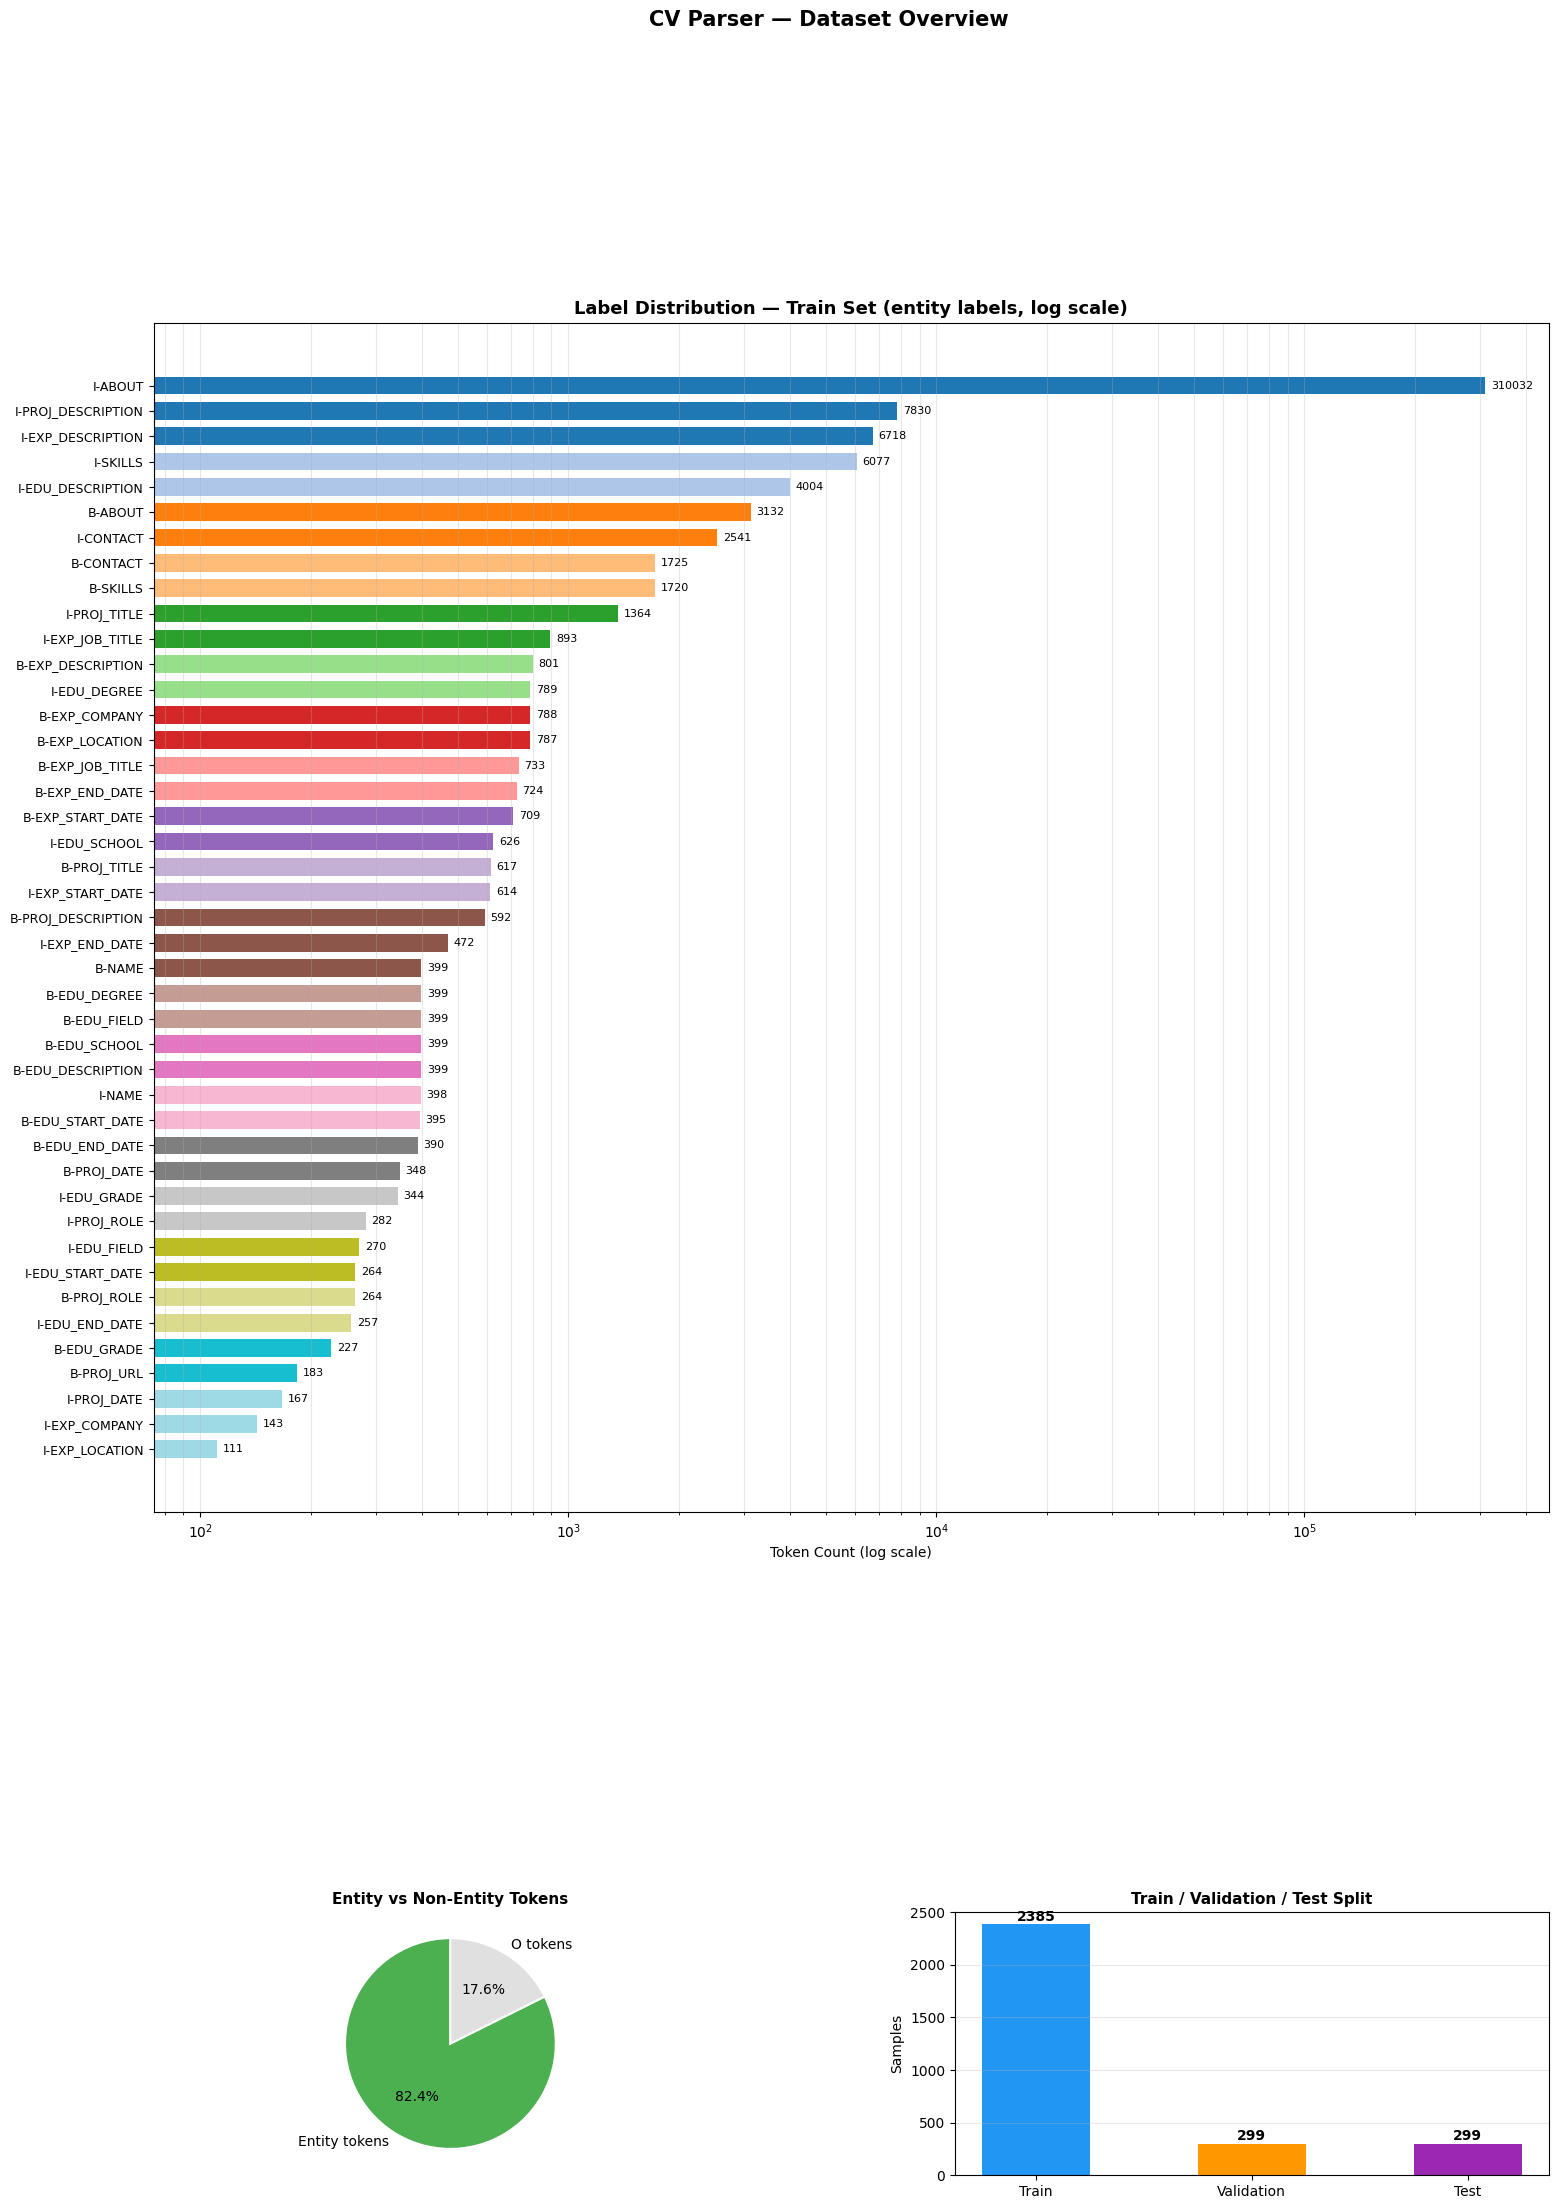

Saved: plot_dataset_summary.png



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
classifier.bias           | MISSING    | 
classifier.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,4.596567,0.832033,0.102432,0.062137,0.077351,0.741274
2,1.399866,0.602460,0.416125,0.486813,0.448702,0.798683
3,1.172259,0.537724,0.561593,0.605275,0.582616,0.800541
4,1.038795,0.503488,0.672331,0.689763,0.680936,0.828822
5,0.938486,0.517100,0.680741,0.706303,0.693287,0.823523


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=375, training_loss=1.6504588470458985, metrics={'train_runtime': 302.2215, 'train_samples_per_second': 39.458, 'train_steps_per_second': 1.241, 'total_flos': 1558587593664000.0, 'train_loss': 1.6504588470458985, 'epoch': 5.0})

In [ ]:
raw_dataset = build_dataset()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, add_prefix_space=True)
tokenized = raw_dataset.map(
    lambda x: tokenize_and_align(x, tokenizer),
    batched=True,
    remove_columns=raw_dataset["train"].column_names,
)

show_dataset_summary(tokenized)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABEL_LIST),
    id2label=ID2LABEL, label2id=LABEL2ID)

_trainer_params = set(inspect.signature(Trainer.__init__).parameters)
_targs_params   = set(inspect.signature(TrainingArguments.__init__).parameters)
_tkn_kwarg  = {"processing_class": tokenizer} if "processing_class" in _trainer_params else {"tokenizer": tokenizer}
_eval_kwarg = "eval_strategy" if "eval_strategy" in _targs_params else "evaluation_strategy"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    **{_eval_kwarg: "epoch"},
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    fp16=True,
    report_to="none",
    gradient_accumulation_steps=2,
    warmup_ratio=0.1,
    dataloader_num_workers=2
)
trainer = Trainer(
    model=model, args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[HistoryCallback()],
    **_tkn_kwarg,
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



  TABLE 3 — Training Metrics per Epoch
+-------+-----------+-----------+--------+--------+----------+
| Epoch | Eval Loss | Precision | Recall |   F1   | Accuracy |
+-------+-----------+-----------+--------+--------+----------+
|   1   |  0.8320   |  0.1024   | 0.0621 | 0.0774 |  0.7413  |
|   2   |  0.6025   |  0.4161   | 0.4868 | 0.4487 |  0.7987  |
|   3   |  0.5377   |  0.5616   | 0.6053 | 0.5826 |  0.8005  |
|   4   |  0.5035   |  0.6723   | 0.6898 | 0.6809 |  0.8288  |
|   5   |  0.5171   |  0.6807   | 0.7063 | 0.6933 |  0.8235  |
+-------+-----------+-----------+--------+--------+----------+

  TABLE 4 — Final Metrics per Entity Label
+------------------+-----------+--------+--------+---------+
|      Label       | Precision | Recall |   F1   | Support |
+------------------+-----------+--------+--------+---------+
|      ABOUT       |  0.3081   | 0.3916 | 0.3449 |   406   |
|     CONTACT      |  0.9665   | 0.9351 | 0.9505 |   185   |
|    EDU_DEGREE    |  0.0000   | 0.0000 | 0.

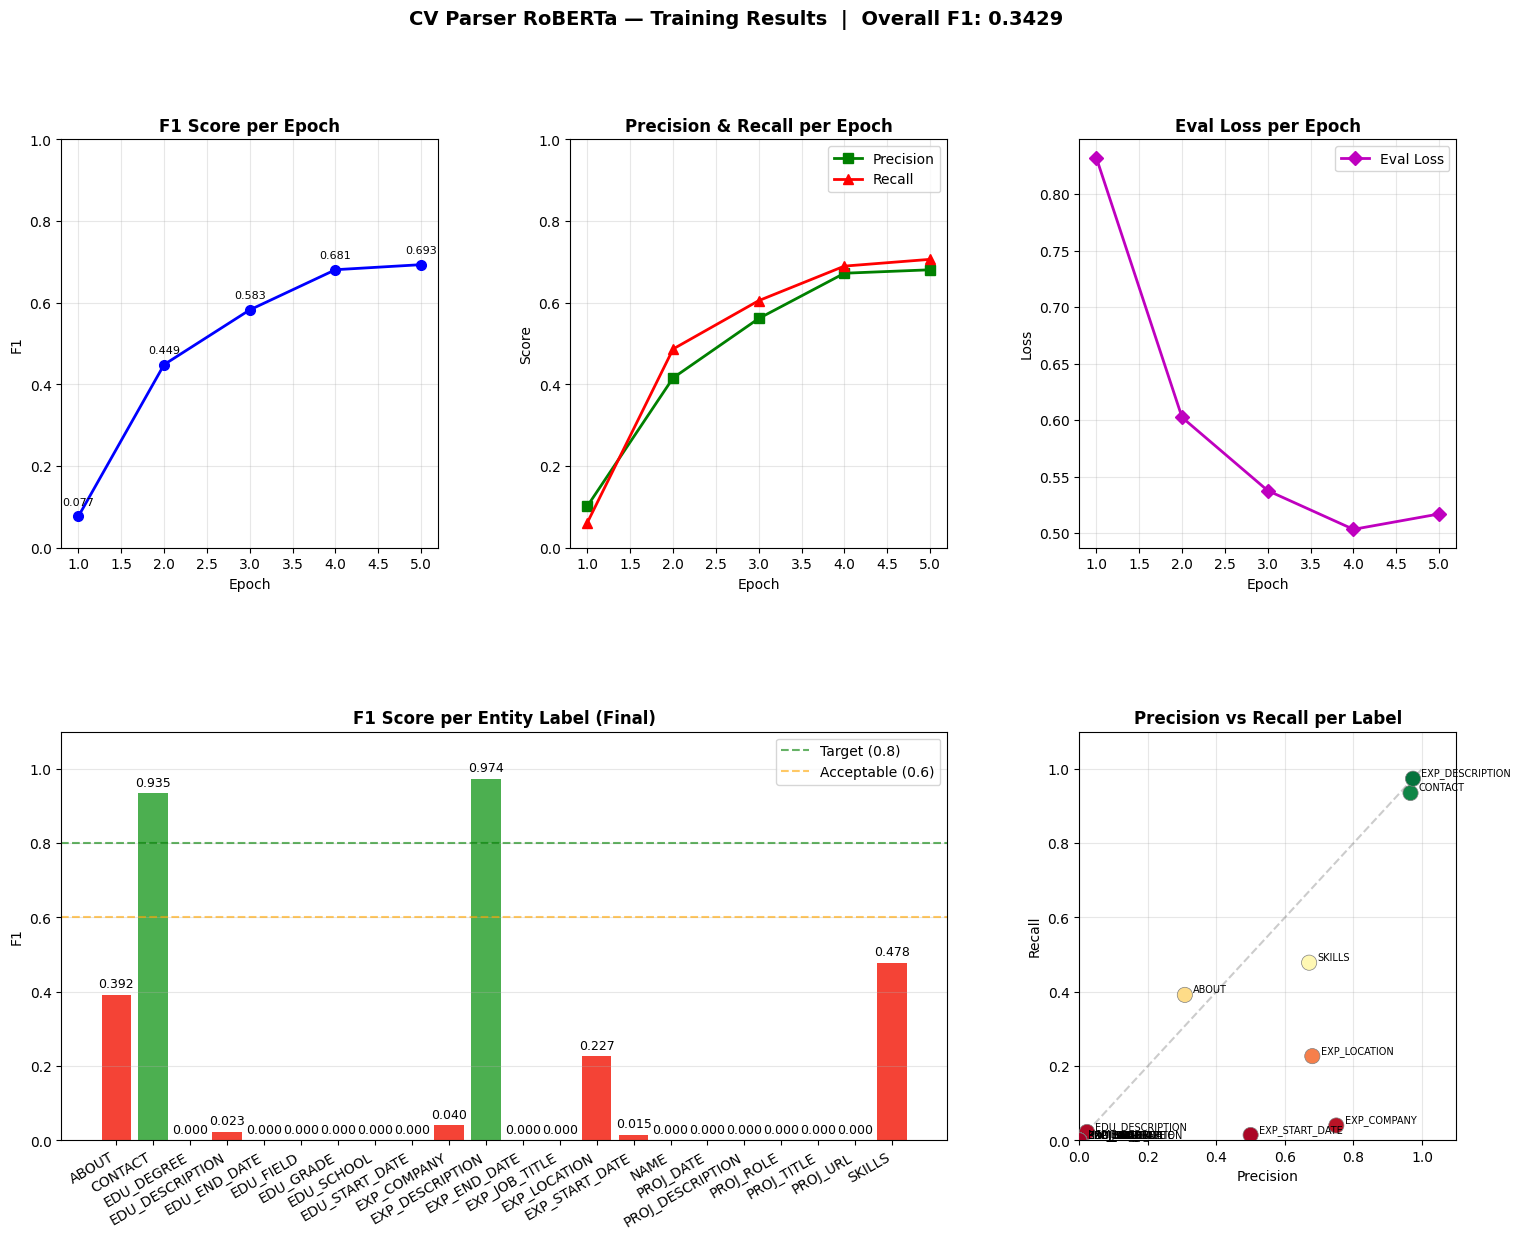

Saved: plot_training_results.png


In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

all_preds_raw = trainer.predict(tokenized["test"])
raw_logits    = all_preds_raw.predictions
raw_labels    = all_preds_raw.label_ids

logits_tensor = torch.tensor(raw_logits)
probs_tensor  = F.softmax(logits_tensor, dim=-1)
raw_preds_ids = probs_tensor.argmax(dim=-1).numpy()
max_probs_np  = probs_tensor.max(dim=-1).values.numpy()

true_preds_all, true_labels_all = [], []
for ps, ls, confs in zip(raw_preds_ids, raw_labels, max_probs_np):
    tp, tl = [], []
    for p_id, l_id, conf in zip(ps, ls, confs):
        if l_id == -100: continue
        effective_pred = p_id if conf >= CONFIDENCE_THRESHOLD else LABEL2ID["O"]
        tp.append(ID2LABEL[effective_pred])
        tl.append(ID2LABEL[l_id])
    true_preds_all.append(tp)
    true_labels_all.append(tl)

detailed      = seqeval_metric.compute(predictions=true_preds_all, references=true_labels_all)
entity_labels = [k for k in detailed if k not in
                 ("overall_precision","overall_recall","overall_f1","overall_accuracy")]
per_label_rows = []
for lbl in sorted(entity_labels):
    d = detailed[lbl]
    per_label_rows.append([lbl, f"{d['precision']:.4f}",
                            f"{d['recall']:.4f}",
                            f"{d.get('f1-score', d.get('f1', 0)):.4f}",
                            d["number"]])
per_label_rows.append([
    "OVERALL",
    f"{detailed['overall_precision']:.4f}",
    f"{detailed['overall_recall']:.4f}",
    f"{detailed['overall_f1']:.4f}",
    sum(detailed[l]["number"] for l in entity_labels),
])

show_training_results(per_label_rows, detailed)


# **SAVE MODEL**

In [ ]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

import json as _json
config_path = f"{OUTPUT_DIR}/config.json"
with open(config_path, "r") as _f:
    cfg = _json.load(_f)
cfg["confidence_threshold"] = CONFIDENCE_THRESHOLD
with open(config_path, "w") as _f:
    _json.dump(cfg, _f, indent=2)

with open(f"{OUTPUT_DIR}/training_history.json", "w") as fh:
    json.dump(training_history, fh, indent=2)

print(f"\n{'='*60}")
print(f"  TRAINING DONE")
print(f"{'='*60}")
print(f"  Overall F1  : {detailed['overall_f1']:.4f}")
print(f"  Precision   : {detailed['overall_precision']:.4f}")
print(f"  Recall      : {detailed['overall_recall']:.4f}")
print(f"  Accuracy    : {detailed['overall_accuracy']:.4f}")
print(f"  Model path  : {OUTPUT_DIR}/")
print(f"{'='*60}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  TRAINING DONE
  Overall F1  : 0.3429
  Precision   : 0.4177
  Recall      : 0.2908
  Accuracy    : 0.7915
  Model path  : ./cv_parser_roberta/


# **DOWNLOAD MODEL**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

# Zip model
shutil.make_archive("cv_parser_roberta", "zip", OUTPUT_DIR)

# Copy ke Google Drive
# shutil.copy("cv_parser_roberta.zip", "/content/drive/MyDrive/cv_parser_roberta.zip")
shutil.copy("plot_dataset_summary.png", "/content/drive/MyDrive/plot_dataset_summary.png")
shutil.copy("plot_training_results.png", "/content/drive/MyDrive/plot_training_results.png")

print("Done! Files saved to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done! Files saved to Google Drive.


In [ ]:
# Verifikasi file tidak corrupt sebelum download
from safetensors import safe_open

model_path = f"{OUTPUT_DIR}/model.safetensors"
try:
    with safe_open(model_path, framework="pt", device="cpu") as f:
        keys = list(f.keys())
    size_mb = os.path.getsize(model_path) / 1e6
    print(f" Model OK — {len(keys)} tensors, {size_mb:.1f} MB")
except Exception as e:
    print(f" Model corrupt: {e}")

✅ Model OK — 199 tensors, 496.4 MB


In [ ]:
import os, zipfile

dst_zip = "/content/drive/MyDrive/cv_parser_roberta.zip"

needed_files = [
    "config.json",
    "model.safetensors",
    "tokenizer.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "vocab.json",
    "merges.txt",
    "training_history.json",
]

with zipfile.ZipFile(dst_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fname in needed_files:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, arcname=fname)
            size_mb = os.path.getsize(fpath) / 1e6
            print(f"  Added: {fname} ({size_mb:.1f} MB)")
        else:
            print(f"  SKIP (not found): {fname}")

final_size = os.path.getsize(dst_zip) / 1e6
print(f"\nDone. Zip size: {final_size:.1f} MB → saved to Google Drive")

  Added: config.json (0.0 MB)
  Added: model.safetensors (496.4 MB)
  Added: tokenizer.json (3.6 MB)
  Added: tokenizer_config.json (0.0 MB)
  SKIP (not found): special_tokens_map.json
  SKIP (not found): vocab.json
  SKIP (not found): merges.txt
  Added: training_history.json (0.0 MB)

Done. Zip size: 442.5 MB → saved to Google Drive
